<img src="https://spire.com/wp-content/themes/spire2021/img/spire-global-cubesat-satellite-logo.svg" width="170" alt="Spire">

# Spire AI-S2S on Earthmover — Indian Monsoon

| Author |
| --- |
| Spire Weather & Climate · AI-S2S team |

---


## Overview

This notebook shows how to **open and use** the Spire AI-S2S hindcast (the full 2026 record, **220+ issuances** to date, from January 1 through 30 days prior to today) from Arraylake — from one
`xr.open_zarr` call to a full **Indian summer monsoon** view: *rainfall anomaly*, *850 hPa
monsoon flow*, *T-max*, *city rainfall fans*, and *regional area means* for **India**. Everything below is driven by data opened straight from the Arraylake catalog repo
`Spire/saifs-s2s-hindcast`.

The monsoon (June–September) delivers ~75 % of India's annual rainfall and drives hydro generation,
cooling demand, kharif sowing, and reservoir operations. Week 1–6 skill on *active* versus *break*
phases is where a sub-seasonal ensemble earns its keep.

### What's in this notebook

1. **Open the dataset** — five zarr groups, latest init, one cell each.
2. **Rainfall + 850 hPa flow, wks 1–6** — precipitation anomaly fill with monsoon wind vectors over *India*.
3. **T-max wks 1–6** — anomaly fill over *India* (heat-stress lens for onset delays and breaks).
4. **City rainfall fans** — ensemble fans with percentile bands at four Indian metros.
5. **Regional area-mean** — daily rainfall anomaly curves for four IMD-style homogeneous regions over the full horizon.

---


## Prerequisites

| Concepts | Importance | Notes |
| --- | --- | --- |
| [Xarray fundamentals](https://docs.xarray.dev/en/stable/getting-started-guide/quick-overview.html) | Necessary | `DataArray`, coords, `.sel` |
| [Arraylake + zarr v3](https://docs.earthmover.io/) | Necessary | how the data is served |
| [matplotlib](https://matplotlib.org/) | Helpful | every plot below is `matplotlib` (+ `cartopy` for maps) |

- **Time to learn**: ~10 minutes
- **Run it**: this notebook is **Colab-ready** — open it in
  [Google Colab](https://colab.research.google.com/), run the first **setup cell** (installs deps
  and runs `arraylake auth login`), then run top to bottom.
- **Prework** (local kernel, optional):
    - `uv sync` &nbsp;— resolve and install the project environment from `pyproject.toml` / `uv.lock`.
    - `uv run python -m ipykernel install --user --name ai-s2s-webinar` &nbsp;— register the kernel this notebook expects.
    - `arraylake auth login` &nbsp;— authenticate to the Arraylake catalog (no AWS credentials needed).


---


## Imports


In [1]:
# --- Colab setup: install deps + authenticate to Arraylake ---
# (Safe to re-run; skip this cell on a local uv-managed kernel.)
# If cartopy fails to import below, uncomment the apt line first.
# !apt-get -qq install -y libgeos-dev libproj-dev proj-bin
%pip install -q arraylake xarray "zarr>=3" dask numpy pandas \
    matplotlib cartopy regionmask shapely



/Users/maxwellgrover/git_repos/spire-earthmover-demo/.claude/worktrees/mighty-stirring-ladybug/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


## Log into Earthmover
You will need to log into your Earthmover Account (https://www.earthmover.io/) and authenticate in this cell.

In [2]:
from arraylake import Client

client = Client()
client.login()

Successfully refreshed tokens! Token stored at /Users/maxwellgrover/.arraylake/token.json

╭───────────────────────────────────────────────── User Details ──────────────────────────────────────────────────╮
│ Name: None None                                                                                                 │
│ Email: maxwell.grover@spire.com                                                                                 │
│ Id: c4434dbc-e8d2-4485-8871-50001ed1dbd4                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Imports

In [3]:
import arraylake
import xarray as xr
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.path as mpath
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask
from shapely.geometry import box

plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 11, 'font.size': 9})


---


## Open the AI-S2S hindcast from Arraylake

Spire AI-S2S hindcasts are published to the Arraylake catalog as the repo
**`Spire/saifs-s2s-hindcast`**. Quick orientation so the rest of the notebook makes sense.

### What's in the dataset

- **Forecast** — 200 ensemble members, **46-day** lead (day 1 → day 46), *daily resolved*.
- **Spatial** — **0.5° global** grid: 361 latitudes × 720 longitudes; longitudes are `[0, 359.5]`.
- **Vertical** — 4 isobaric levels for upper-air variables: **200 / 500 / 850 / 1000 hPa**.
- **Layout** — split into **five zarr groups**, each on the same
  `(reference_time, step, latitude, longitude)` grid for the GRIB groups, plus a compact
  `regimes` group keyed by `(reference_time, step, regime)`:

| Group | What's inside |
| :--- | :--- |
| **`mean_stddev`**   | ensemble *mean* and *standard deviation* — temperature, wind, precipitation, pressure, radiation, geopotential height, specific humidity |
| **`percentiles`**   | `<var>_pctl` at `[1, 5, 10, 20, 50, 80, 90, 95, 99]` across the 200 members |
| **`probabilities`** | probability of falling in climatological *terciles / quintiles / deciles* and above-normal vs ERA5 1991–2020 |
| **`anomalies`**     | *departures* from the ERA5 1991–2020 climatological mean |
| **`regimes`**       | CONUS (5) and EUATL (8) weather-regime probabilities — `(reference_time, step, regime)` |

### How it's stored

- **Icechunk** repository backed by **zarr v3**, served through the **Arraylake** catalog — a
  transactional, branchable storage layer for analysis-ready scientific data.
- Every GRIB variable is chunked `(1, 1, 361, 720)` along `(reference_time, step, lat, lon)` —
  so *a single global map at one init + one lead is **one chunk = one read***.
- **Full record, preallocated** — the store has **1096 `reference_time` slots** (three years of daily
  inits) and currently holds **221 valid issuances**, 2026-01-01 → 2026-08-09. Slots are written as inits
  arrive, so the on-disk order is *not* chronological — always `sortby('reference_time')` — and unused
  slots are NaT-filled, so pick the latest *non-NaT* `reference_time`.
- **Real-time sibling** — `Spire/saifs-s2s-daily` carries the same layout as a 15-issuance rolling window;
  everything below works unchanged against it.
- The store is opened through the **Arraylake** client (`arraylake.Client().get_repo(...)`) —
  authenticate once with `arraylake auth login`; no AWS credentials needed.

### The open recipe

One `xr.open_zarr` call per group, against the read-only `main` branch session — that's it.


In [4]:
# 1.  Open the hindcast via the Arraylake catalog (auth from `arraylake auth login`).
client = arraylake.Client()
repo   = client.get_repo("Spire/saifs-s2s-hindcast")
ro     = repo.readonly_session(branch="main")

# 2.  Open each zarr group as an xarray.Dataset.
def open_group(group):
    return xr.open_zarr(ro.store, group=group, zarr_format=3).sortby('reference_time')

mean    = open_group('mean_stddev')
pctl    = open_group('percentiles')
prob    = open_group('probabilities')
anom    = open_group('anomalies')
regimes = open_group("regimes")

# 3.  Pick the latest non-NaT issuance (rolling-window slots are NaT-filled).
rt          = pd.to_datetime(anom.reference_time.values)
VALID_INITS = rt[~pd.isna(rt)].sort_values()
INIT_TS     = VALID_INITS[-1]
INIT        = INIT_TS.strftime('%Y-%m-%d')
STEPS = (mean.step.values.astype(int)
         if mean.step.dtype.kind in 'iu'
         else (mean.step / np.timedelta64(1, 'D')).astype(int).values)

# 4.  Quick shape summary across all 5 groups.
print(f'Valid inits : {len(VALID_INITS)}  ({VALID_INITS[0]:%Y-%m-%d} → {VALID_INITS[-1]:%Y-%m-%d}; '
      f'{anom.sizes["reference_time"]} slots allocated)')
print(f'Latest init : {INIT}')
print(f'Lead horizon: day {STEPS[0]} → day {STEPS[-1]}  (daily)')
print(f'Grid        : {mean.sizes["latitude"]} × {mean.sizes["longitude"]}  @ 0.5°\n')
for name, ds in [('mean_stddev',  mean),
                 ('percentiles',  pctl),
                 ('probabilities', prob),
                 ('anomalies',    anom),
                 ('regimes',      regimes)]:
    print(f'  {name:14s}  vars={len(ds.data_vars):3d}   dims={dict(ds.sizes)}')


  2026-09-17T05:09:56.744286Z  WARN aws_runtime::env_config::normalize: profile `[default]` ignored because `[profile default]` was found which takes priority
    at /Users/runner/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-runtime-1.7.2/src/env_config/normalize.rs:136



Valid inits : 229  (2026-01-01 → 2026-08-17; 1096 slots allocated)
Latest init : 2026-08-17
Lead horizon: day 1 → day 46  (daily)
Grid        : 361 × 720  @ 0.5°

  mean_stddev     vars= 36   dims={'reference_time': 1096, 'step': 46, 'latitude': 361, 'longitude': 720, 'isobar': 2}
  percentiles     vars= 13   dims={'reference_time': 1096, 'step': 46, 'percentile': 9, 'latitude': 361, 'longitude': 720}
  probabilities   vars= 84   dims={'reference_time': 1096, 'step': 46, 'latitude': 361, 'longitude': 720}
  anomalies       vars= 10   dims={'reference_time': 1096, 'step': 46, 'latitude': 361, 'longitude': 720, 'isobar': 2}
  regimes         vars=  2   dims={'reference_time': 1096, 'step': 46, 'conus_regime': 5, 'euatl_regime': 8}


### Peek at one variable

Pick one variable (2-m mean temperature) at the **latest init** and let xarray show its
structure: `(step, latitude, longitude) = (46, 361, 720)`, with **dask chunks of
`(1, 361, 720)`** — one global map per chunk. Nothing has actually been read from S3 yet; the
data only loads when you call `.values`, `.load()`, or render a plot.


In [5]:
mean['air_temperature'].sel(reference_time=INIT)


<xarray.DataArray 'air_temperature' (step: 46, latitude: 361, longitude: 720)> Size: 48MB
dask.array<getitem, shape=(46, 361, 720), dtype=float32, chunksize=(1, 361, 720), chunktype=numpy.ndarray>
Coordinates:
  * step            (step) timedelta64[D] 368B 1 days 2 days ... 45 days 46 days
  * latitude        (latitude) float64 3kB 90.0 89.5 89.0 ... -89.0 -89.5 -90.0
  * longitude       (longitude) float64 6kB 0.0 0.5 1.0 ... 358.5 359.0 359.5
    reference_time  datetime64[ns] 8B 2026-08-17
Attributes:
    standard_name:  air_temperature
    units:          K
    long_name:      2m air temperature
    description:    Air temperature at 2 metres above the surface. 24-hour en...

---


## Small helpers

Unit conversion, longitude wrap, weekly lead-day buckets (**six** of them — wk 1 … wk 6), and a
a map base for **North America**.


In [6]:
K_to_C = lambda K: K - 273.15          # absolute temperatures; anomalies in K are already °C

def to_180(da):
    return da.assign_coords(longitude=(((da.longitude + 180) % 360) - 180)).sortby('longitude')

def area_mean(da, mask, rid):
    w = np.cos(np.deg2rad(da.latitude))
    return da.where(mask == rid).weighted(w).mean(('latitude', 'longitude'))

def sym(da, q=98):
    v = float(np.nanpercentile(np.abs(da.values), q));  return (-v, v)

# Six-week buckets — wk 1 … wk 6, seven days each.
WEEKS = {f'Wk {w}': np.where((STEPS >= 1 + 7*(w-1)) & (STEPS <= 7*w))[0]
         for w in range(1, 7)}

# Region domain — India and the surrounding monsoon basin (Arabian Sea to Bay of Bengal).
IN = dict(lat=(5, 40), lon=(60, 100))

def setup_geoax(ax, region):
    ax.coastlines('50m', linewidth=0.5)
    ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=0.4)
    ax.set_extent([*region['lon'], *region['lat']], crs=ccrs.PlateCarree())

def region_slice(da, region):
    return (to_180(da).sel(latitude=slice(region['lat'][1], region['lat'][0]),
                             longitude=slice(*region['lon'])))

---


## India · rainfall anomaly + 850 hPa flow, wks 1–6

**Start with the monsoon engine.**

- **Fill** — *daily precipitation anomaly* &nbsp;·&nbsp; `anomalies` group &nbsp;·&nbsp; mm/day vs ERA5 1991–2020
- **Arrows** — *850 hPa ensemble-mean wind* &nbsp;·&nbsp; `mean_stddev` group &nbsp;·&nbsp; m/s

The 850 hPa arrows show the **cross-equatorial south-westerlies** (Somali jet) feeding the Arabian Sea
branch and the **Bay of Bengal** branch curving into the monsoon trough. Green = wetter than normal
(*active* phase), brown = drier (*break*). Each panel is the **7-day mean** over the corresponding
forecast week, all panels on a *shared symmetric color scale* so weeks compare directly.

In [7]:
def precip_wind_maps(region, region_name, stride=6):
    pr_all = region_slice(anom.precipitation_amount.sel(reference_time=INIT), region).load()
    u_all  = region_slice(mean.eastward_wind_at_isobaric_levels .sel(reference_time=INIT, isobar=85000), region).load()
    v_all  = region_slice(mean.northward_wind_at_isobaric_levels.sel(reference_time=INIT, isobar=85000), region).load()
    clim = sym(pr_all)
    fig, axes = plt.subplots(2, 3, figsize=(15, 8.5), layout='constrained',
                             subplot_kw={'projection': ccrs.PlateCarree()})
    for ax, (week_label, idx) in zip(axes.flat, WEEKS.items()):
        pr_w = pr_all.isel(step=idx).mean('step')
        u_w  = u_all .isel(step=idx).mean('step')
        v_w  = v_all .isel(step=idx).mean('step')
        lon, lat = pr_w.longitude.values, pr_w.latitude.values
        mesh = ax.pcolormesh(lon, lat, pr_w.values, transform=ccrs.PlateCarree(),
                             cmap='BrBG', vmin=clim[0], vmax=clim[1], shading='auto')
        q = ax.quiver(lon[::stride], lat[::stride],
                      u_w.values[::stride, ::stride], v_w.values[::stride, ::stride],
                      transform=ccrs.PlateCarree(), color='k', scale=250, width=0.0025)
        setup_geoax(ax, region)
        ax.set_title(f'{region_name} · {week_label}')
    ax.quiverkey(q, 0.78, -0.08, 10, '10 m/s', labelpos='E', coordinates='axes')
    fig.colorbar(mesh, ax=axes, orientation='horizontal', shrink=0.6, pad=0.03,
                 label='precipitation anomaly (mm/day)')
    return fig

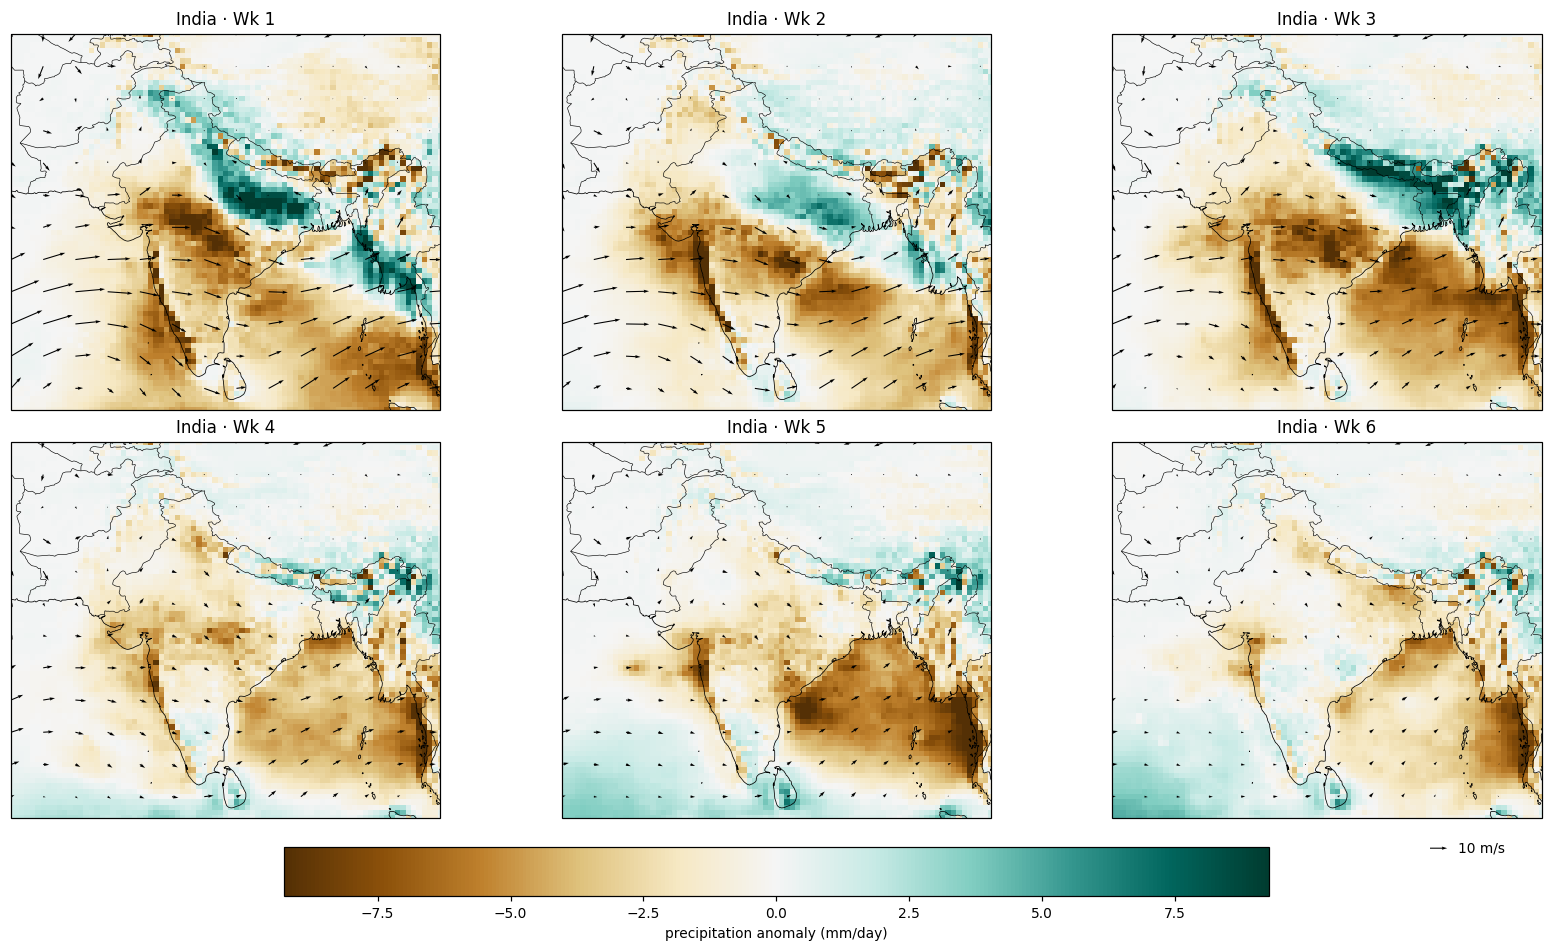

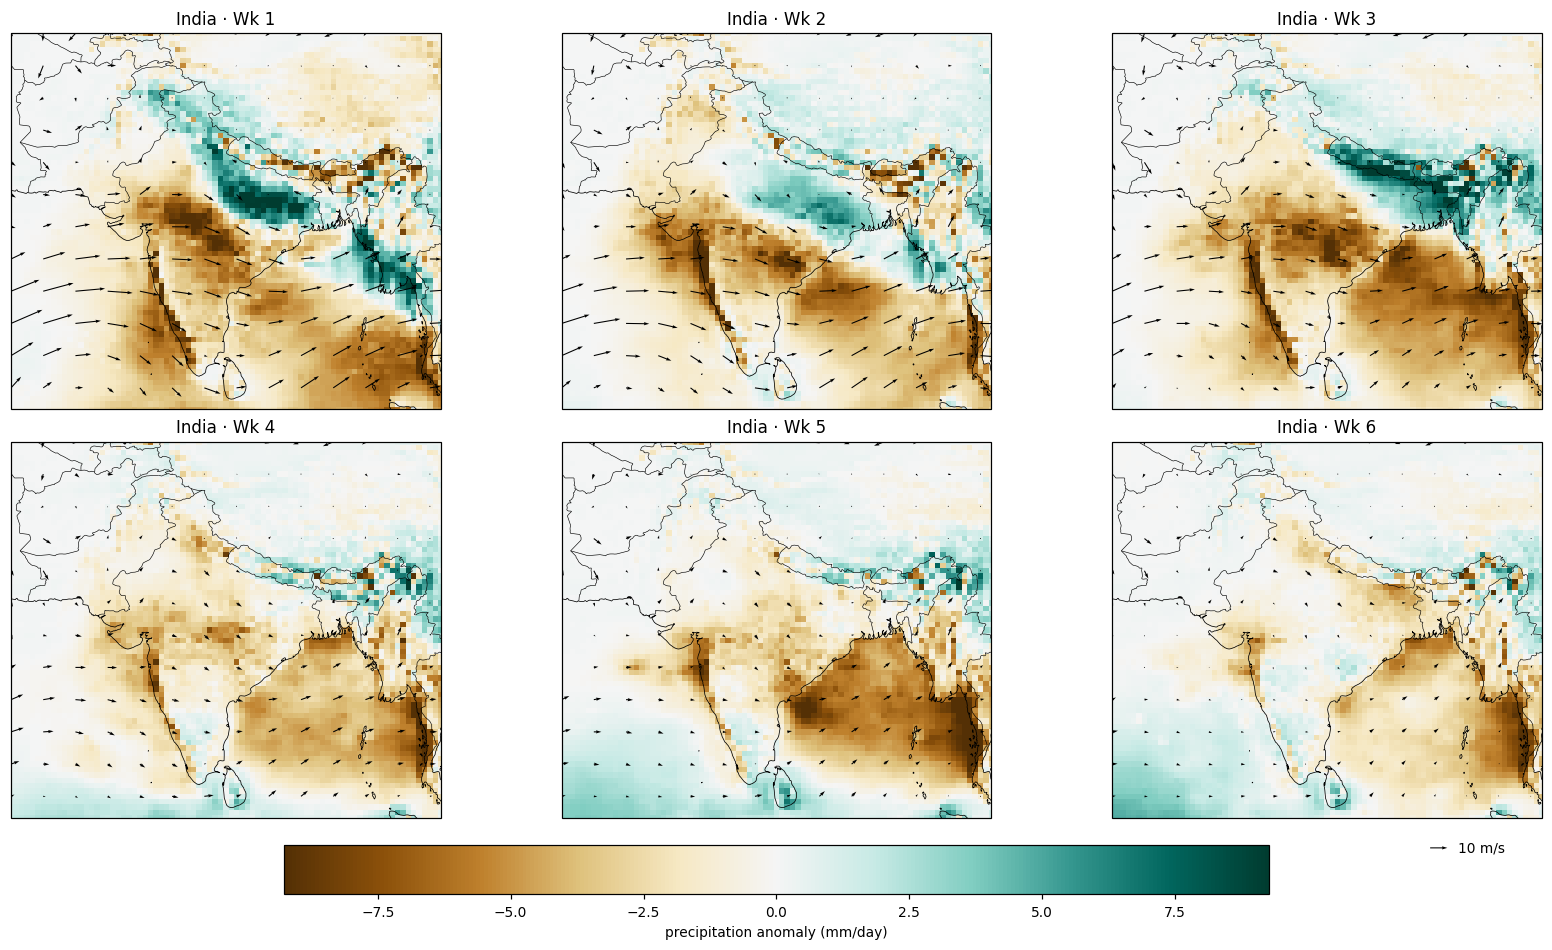

In [8]:
precip_wind_maps(IN, 'India')

---


## India · daily T-max anomaly, wks 1–6

**One field, six panels.**

- **Fill** — T-max **anomaly** &nbsp;·&nbsp; `anomalies` group &nbsp;·&nbsp; *°C vs ERA5 1991–2020*

A delayed onset or a monsoon *break* shows up here first: warm anomalies over the Indo-Gangetic
plain and central India mean **heat stress** and **cooling load**; cool anomalies track cloud cover
and rain. Each panel is the **7-day mean** over the corresponding forecast week, on a *common
symmetric scale*.

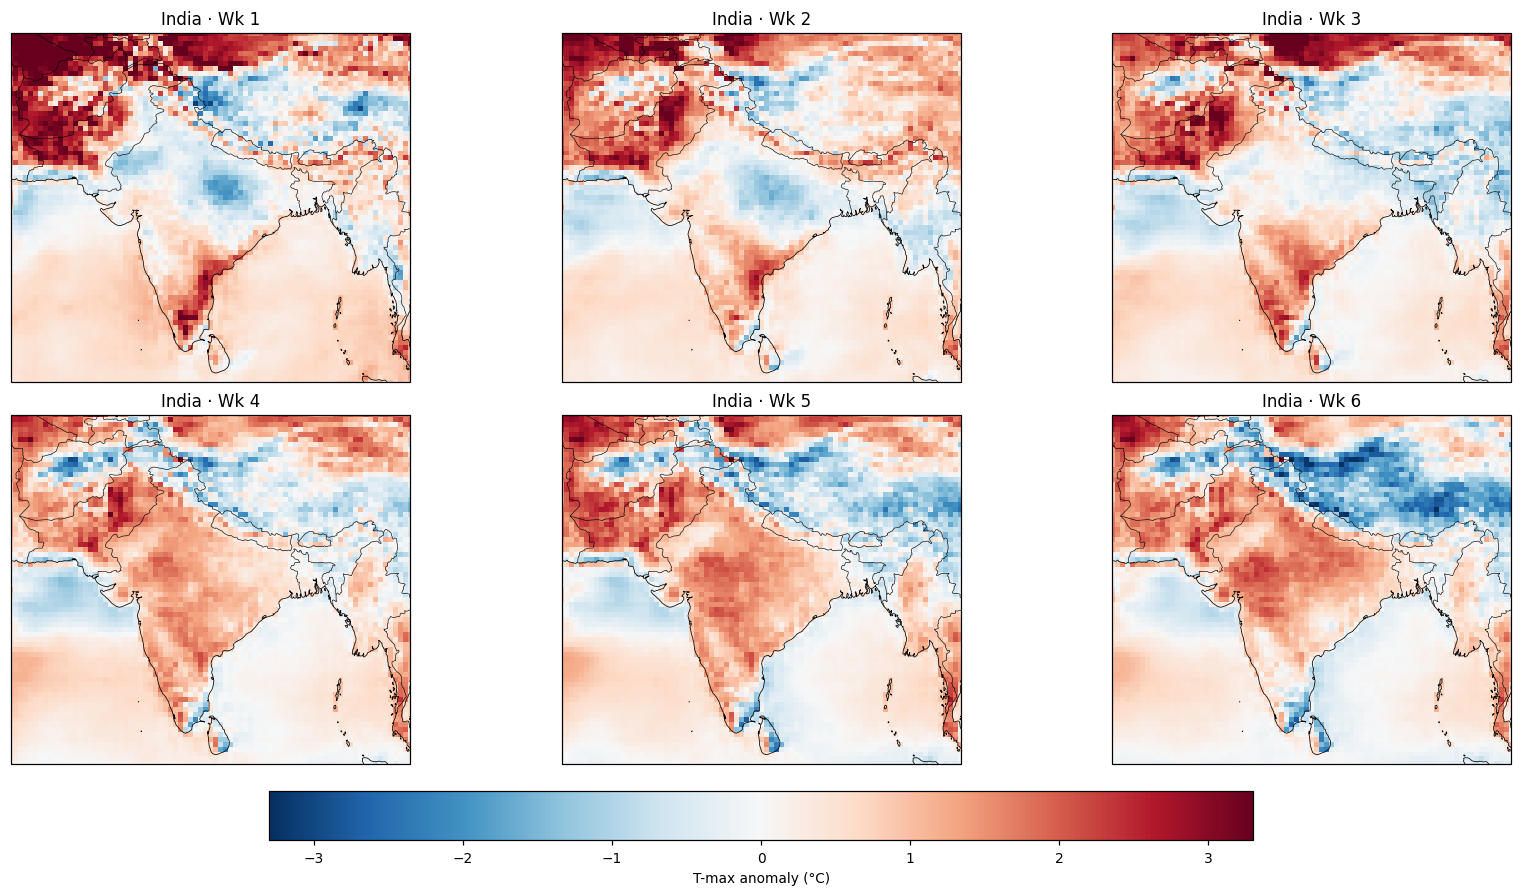

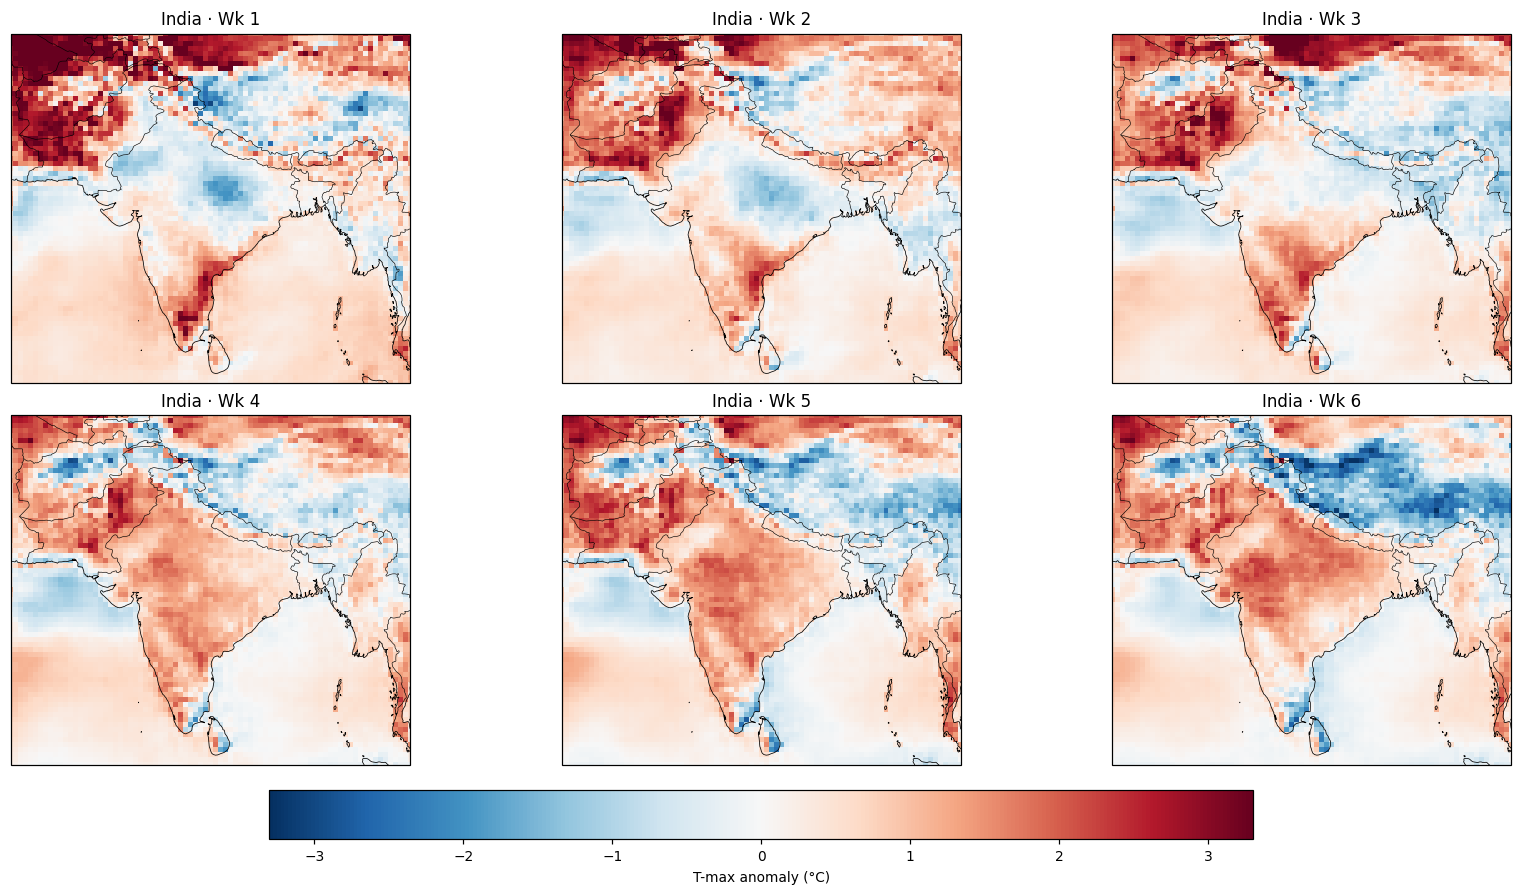

In [9]:
def t_maps(region, region_name):
    anom_all = region_slice(anom.air_temperature_max.sel(reference_time=INIT), region).load()
    clim = sym(anom_all)
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), layout='constrained',
                             subplot_kw={'projection': ccrs.PlateCarree()})
    for ax, (week_label, idx) in zip(axes.flat, WEEKS.items()):
        anom_w = anom_all.isel(step=idx).mean('step')
        lon, lat = anom_w.longitude.values, anom_w.latitude.values
        mesh = ax.pcolormesh(lon, lat, anom_w.values, transform=ccrs.PlateCarree(),
                             cmap='RdBu_r', vmin=clim[0], vmax=clim[1], shading='auto')
        setup_geoax(ax, region)
        ax.set_title(f'{region_name} · {week_label}')
    fig.colorbar(mesh, ax=axes, orientation='horizontal', shrink=0.6, pad=0.03,
                 label='T-max anomaly (°C)')
    return fig

t_maps(IN, 'India')

---


## Indian metros — daily rainfall **ensemble fan**

**All 200 members at a point**, summarized by the **`percentiles`** group.

- **Nested bands** — *1–99 %* / *5–95 %* / *10–90 %* / *20–80 %*
- **Solid line** — ensemble mean (from `mean_stddev`)
- **Dotted line** — median (from `percentiles`)

*Four metros spanning the monsoon's branches — Mumbai on the Arabian Sea coast, Kolkata at the head of
the Bay of Bengal, Delhi on the Indo-Gangetic plain, Chennai in the rain-shadow of the south-west
monsoon.* Rainfall is heavy-tailed, so the mean sits well above the median on wet days.

> **Day 1** in the `percentiles` group carries no ensemble spread for precipitation in the current store
> (all percentiles collapse onto one value), so read the fans from **day 2** onward.

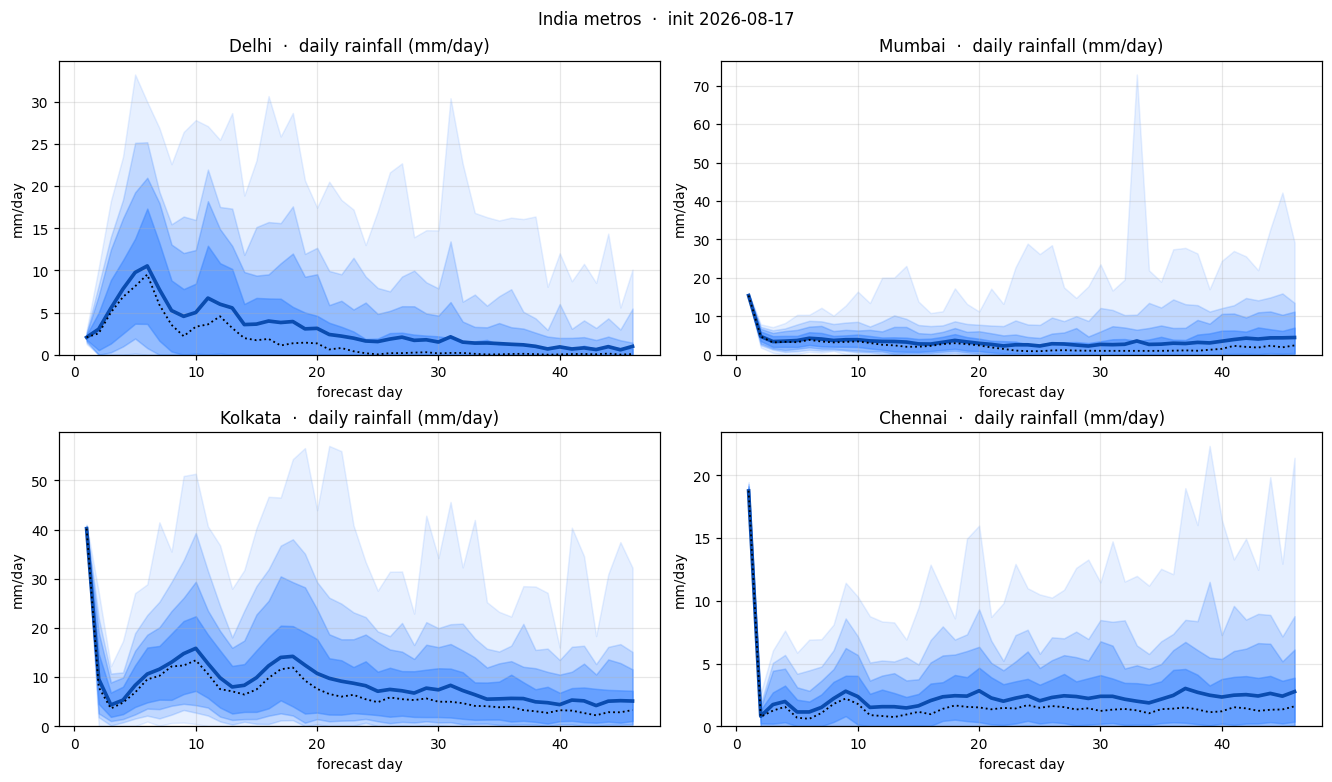

In [10]:
HUBS_IN = {
    'Delhi'   : (28.61, 77.21),
    'Mumbai'  : (19.08, 72.88),
    'Kolkata' : (22.57, 88.36),
    'Chennai' : (13.08, 80.27),
}
def fan(ax, name, lat, lon):
    lon360 = lon % 360
    # Select reference_time exactly first (the hindcast store's reference_time
    # coord includes NaT-filled slots, which makes a combined .sel(..., method='nearest')
    # reindex blow up — split it.
    p = (pctl.precipitation_amount_pctl
             .sel(reference_time=INIT)
             .sel(latitude=lat, longitude=lon360, method='nearest')).load()
    m = (mean.precipitation_amount
             .sel(reference_time=INIT)
             .sel(latitude=lat, longitude=lon360, method='nearest')).load()
    for lo, hi, a, lbl in [(1, 99, 0.12, '1–99 %'),
                           (5, 95, 0.22, '5–95 %'),
                           (10, 90, 0.34, '10–90 %'),
                           (20, 80, 0.50, '20–80 %')]:
        ax.fill_between(STEPS, p.sel(percentile=lo).values, p.sel(percentile=hi).values,
                        color='#3a86ff', alpha=a, label=lbl)
    ax.plot(STEPS, m.values, color='#0a4cb0', lw=2.4, label='ens-mean')
    ax.plot(STEPS, p.sel(percentile=50).values, color='k', lw=1.2, ls=':', label='median')
    ax.set_ylim(bottom=0)
    ax.set_title(f'{name}  ·  daily rainfall (mm/day)')
    ax.set_xlabel('forecast day'); ax.set_ylabel('mm/day')
    ax.grid(True, alpha=0.3)

def fan_grid(hubs, suptitle):
    fig, axes = plt.subplots(2, 2, figsize=(12, 7), layout='constrained')
    for ax, (n, (lat, lon)) in zip(axes.flat, hubs.items()):
        fan(ax, n, lat, lon)
    fig.suptitle(suptitle)
    return fig

fan_grid(HUBS_IN, f'India metros  ·  init {INIT}');

---


## Homogeneous regions — area-mean daily rainfall **anomaly** over the full horizon

*Cosine-weighted* area mean of the **`anomalies`** precipitation field for four boxes approximating
the IMD homogeneous monsoon regions — **all on one chart**.

> **Zero line = ERA5 1991–2020 climatology.**

Excursions above / below are *the monsoon story*: a sustained **wet** departure over Central India is
an active spell (hydro inflows, lower cooling load); a sustained **dry** departure across Northwest and
Central India is a break (irrigation draw, peaking demand).

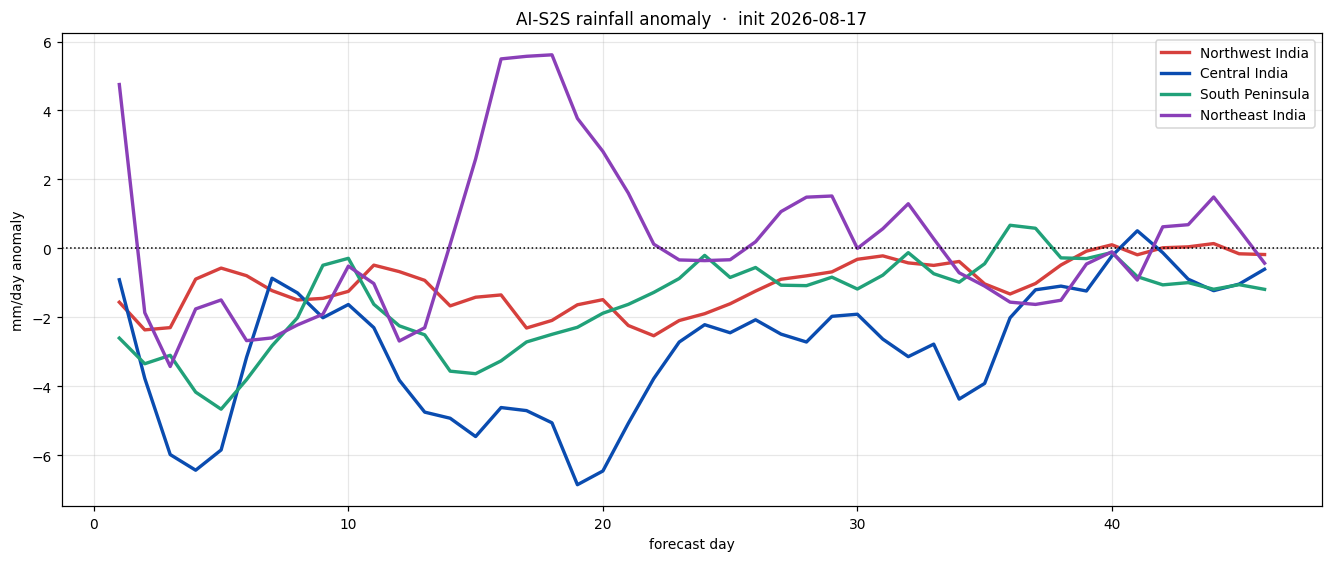

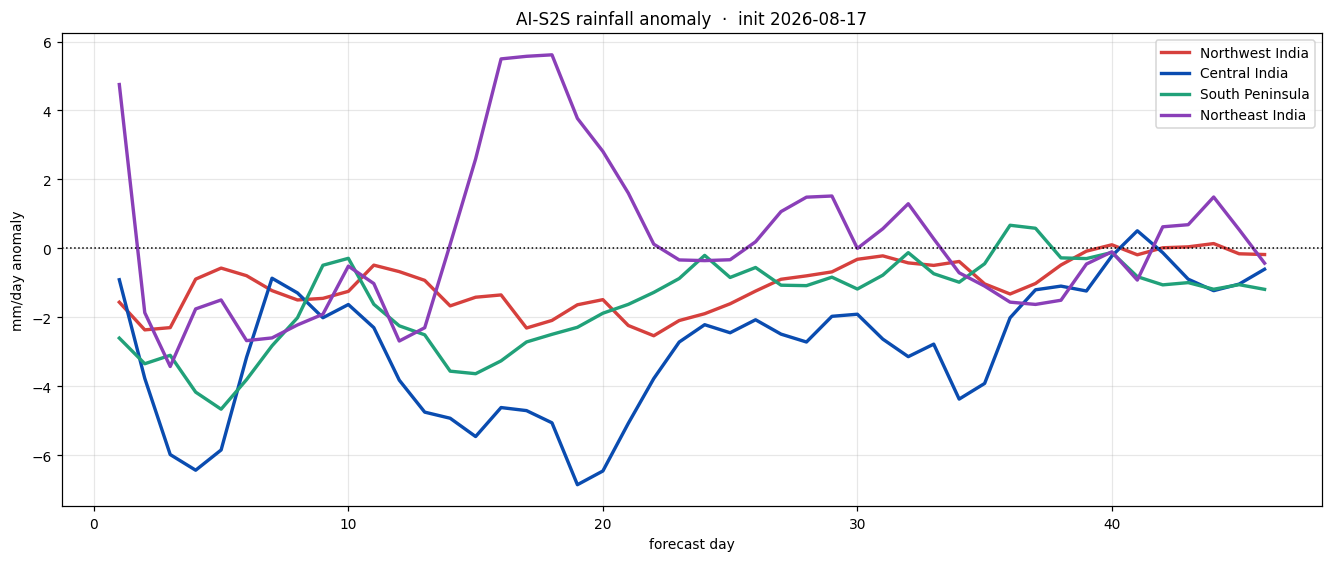

In [11]:
REGIONS = regionmask.Regions(
    outlines=[
        box(68, 23, 78, 32),    # Northwest India (Rajasthan, Punjab, Haryana, Delhi)
        box(74, 17, 87, 23),    # Central India (MP, Maharashtra interior, Chhattisgarh, Odisha)
        box(74,  8, 81, 17),    # South Peninsula (Karnataka, Kerala, Tamil Nadu, Andhra)
        box(88, 22, 97, 29),    # Northeast India (West Bengal, Assam, Meghalaya)
    ],
    names  =['Northwest India', 'Central India', 'South Peninsula', 'Northeast India'],
    abbrevs=['NW', 'CEN', 'SP', 'NE'],
    name='IMD-style homogeneous regions',
)

a_pr = to_180(anom.precipitation_amount.sel(reference_time=INIT)).sel(latitude=slice(40, 5)).load()
mask = REGIONS.mask(a_pr.longitude, a_pr.latitude)

COLORS = {'Northwest India': '#d6403d', 'Central India': '#0a4cb0',
          'South Peninsula': '#21a179', 'Northeast India': '#8a3fb8'}

fig, ax = plt.subplots(figsize=(12, 5), layout='constrained')
for reg in REGIONS.names:
    rid = REGIONS.map_keys(reg)
    y   = area_mean(a_pr, mask, rid).values
    ax.plot(STEPS, y, color=COLORS[reg], lw=2.2, label=reg)
ax.axhline(0, color='k', ls=':', lw=1)
ax.set_title(f'AI-S2S rainfall anomaly  ·  init {INIT}')
ax.set_xlabel('forecast day'); ax.set_ylabel('mm/day anomaly')
ax.legend(loc='upper right'); ax.grid(True, alpha=0.3)
fig

---


## Summary

Five `xr.open_zarr` calls on Arraylake and the full monsoon view falls out: **rainfall anomaly
and 850 hPa flow**, **T-max**, **city rainfall fans**, **regional area means** — for **India**.

### Resources

- Earthmover marketplace — [app.earthmover.io/marketplace](https://app.earthmover.io/marketplace)
- Earthmover docs — [docs.earthmover.io](https://docs.earthmover.io/)